# Smart Harvest AI — Crop Yield EDA, Feature Engineering and XGBoost

This notebook trains a replacement candidate from `crop_yield.csv` while preserving the Flask application contract: categorical label encoders, a scaler, the existing 15-feature schema where possible, and artifacts written to a separate `models/yield_model_crop_yield_candidate/` directory. Review the metrics before copying artifacts into production.

Important: `Production` is excluded because it is direct target leakage when predicting `Yield`. The source dataset has no district, coordinates, humidity, pH, organic carbon, clay, or sand columns, so those existing application inputs cannot be learned from this dataset and are not included in this candidate model.

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
ROOT = Path.cwd()
if not (ROOT / 'crop_yield.csv').exists():
    ROOT = Path.cwd().parent
DATA_PATH = ROOT / 'crop_yield.csv'
OUTPUT_DIR = ROOT / 'models' / 'yield_model_crop_yield_candidate'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Project root:', ROOT)
print('Output directory:', OUTPUT_DIR)

Project root: /Users/ayushvishnoi/Documents/GitHub/smart_harvest.ai
Output directory: /Users/ayushvishnoi/Documents/GitHub/smart_harvest.ai/models/yield_model_crop_yield_candidate


## 1. Load and inspect the data

In [2]:
df = pd.read_csv(DATA_PATH)
df.columns = (df.columns.str.strip().str.lower().str.replace(' ', '_'))
print(f'Rows: {len(df):,} | Columns: {df.shape[1]}')
display(df.head())
display(pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing': df.isna().sum(), 'unique': df.nunique()}))
display(df.describe(include='all').transpose())

Rows: 19,689 | Columns: 10


,crop,crop_year,season,state,area,production,annual_rainfall,fertilizer,pesticide,yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


,dtype,missing,unique
crop,object,0,55
crop_year,int64,0,24
season,object,0,6
state,object,0,30
area,float64,0,13644
production,int64,0,14016
annual_rainfall,float64,0,634
fertilizer,float64,0,18598
pesticide,float64,0,17405
yield,float64,0,13551


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
crop,19689,55,Rice,1197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
crop_year,19689.0,NaN,NaN,NaN,2009.127584,6.498099,1997.0,2004.0,2010.0,2015.0,2020.0
season,19689,6,Kharif,8232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,19689,30,Karnataka,1432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,19689.0,NaN,NaN,NaN,179926.570308,732828.675888,0.5,1390.0,9317.0,75112.0,50808100.0
production,19689.0,NaN,NaN,NaN,16435941.273097,263056839.812567,0.0,1393.0,13804.0,122718.0,6326000000.0
annual_rainfall,19689.0,NaN,NaN,NaN,1437.755177,816.909589,301.3,940.7,1247.6,1643.7,6552.7
fertilizer,19689.0,NaN,NaN,NaN,24103312.448806,94946004.482527,54.17,188014.62,1234957.44,10003847.2,4835406877.0
pesticide,19689.0,NaN,NaN,NaN,48848.353392,213287.35486,0.09,356.7,2421.9,20041.7,15750511.0
yield,19689.0,NaN,NaN,NaN,79.954009,878.306193,0.0,0.6,1.03,2.388889,21105.0


## 2. EDA: distributions, relationships and group summaries

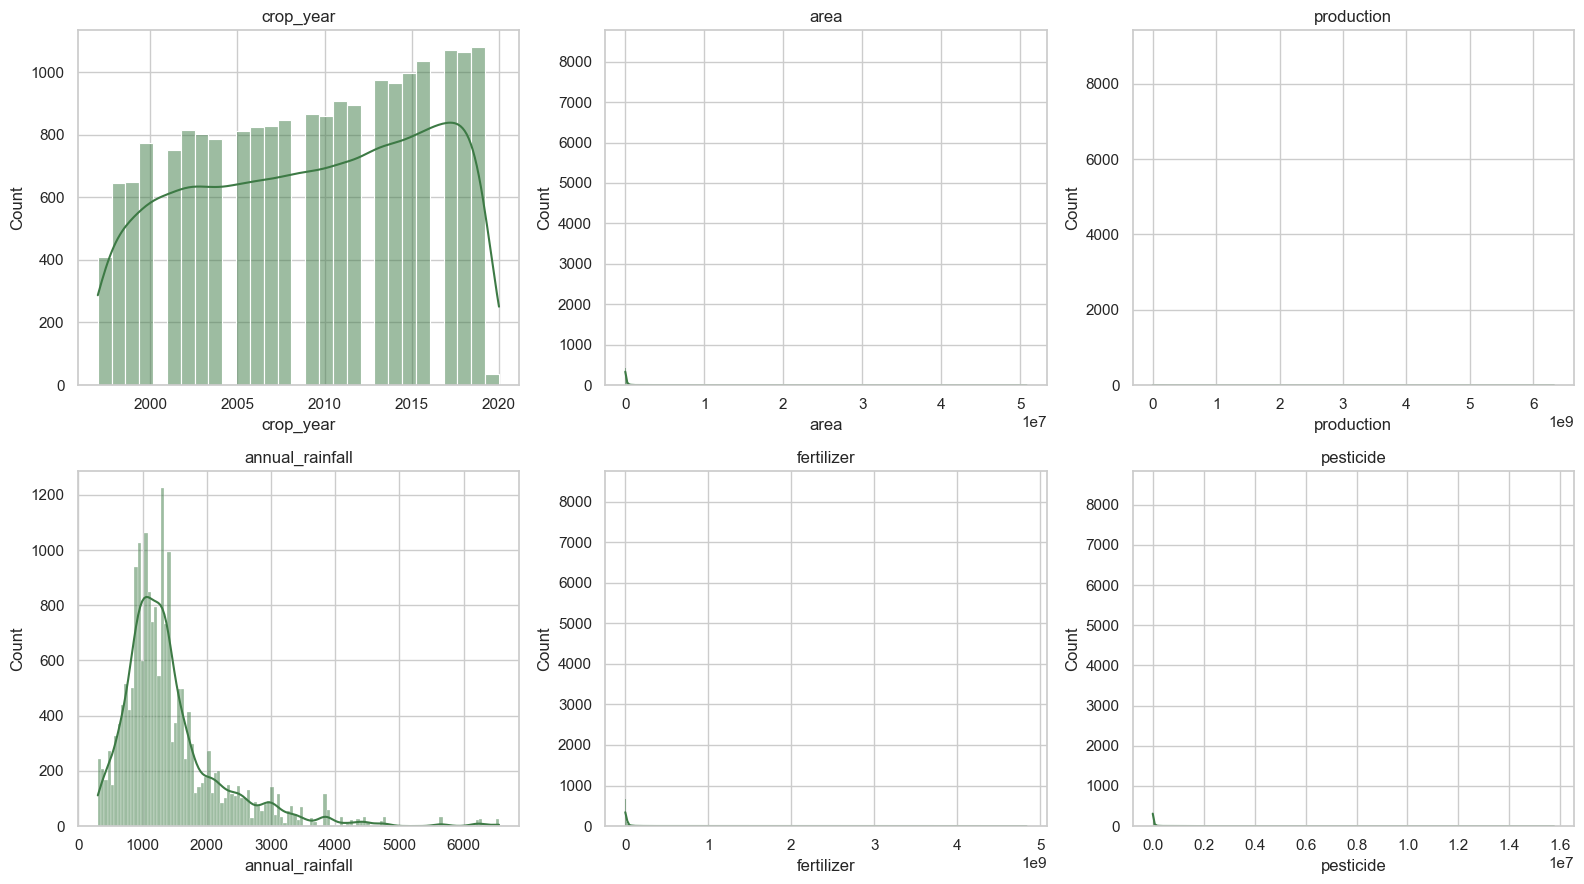

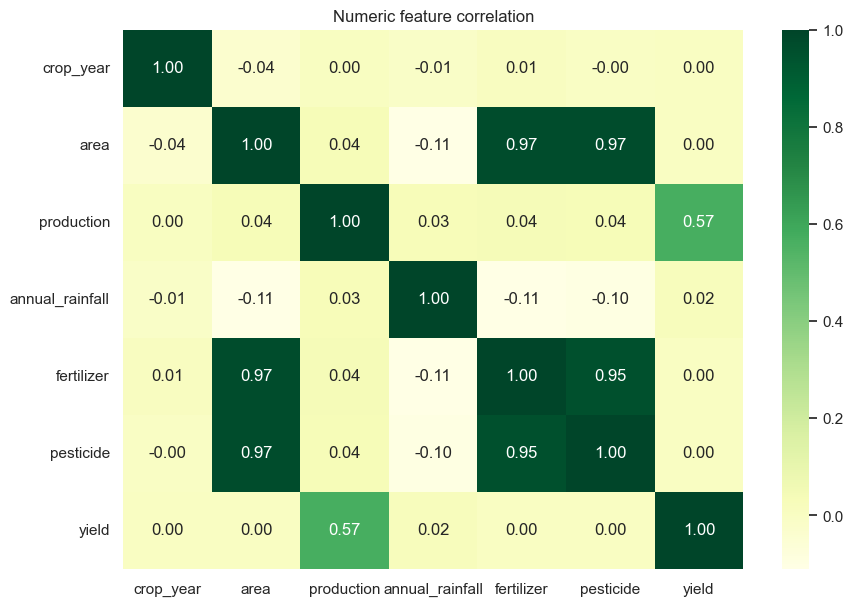

,count,mean,median,std
crop,,,,
Rice,1197,2.218495,2.203636,0.802459
Maize,975,3.427216,1.955455,31.688399
Moong(Green Gram),740,0.530940,0.511258,0.253417
Urad,733,0.584048,0.570000,0.301862
Groundnut,725,1.360983,1.195000,0.623429
Sesamum,685,0.611750,0.438000,2.912262
Potato,628,13.331718,10.175284,20.328776
Sugarcane,605,51.727439,53.158158,30.608713
Wheat,545,2.005086,1.668462,1.080466


,count,mean,median
state,,,
Karnataka,1432,105.720578,1.011905
Andhra Pradesh,1266,181.465391,1.132187
West Bengal,1094,266.898311,0.950000
Chhattisgarh,915,1.966733,0.495556
Bihar,896,3.476499,1.066982
Madhya Pradesh,845,3.457816,0.875000
Uttar Pradesh,825,5.053113,1.206296
Tamil Nadu,822,226.050221,1.487136
Gujarat,817,6.697227,1.314706


,count,mean,median
season,,,
Whole Year,3717,412.995463,4.295122
Winter,389,5.287267,1.545333
Autumn,414,3.917482,1.091677
Summer,1195,2.997370,1.673750
Kharif,8232,2.482002,0.924226
Rabi,5742,1.988518,0.902660


In [3]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, numeric_cols[:6]):
    sns.histplot(df[col], kde=True, ax=ax, color='#3d7a45')
    ax.set_title(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='YlGn')
plt.title('Numeric feature correlation')
plt.show()

display(df.groupby('crop')['yield'].agg(['count', 'mean', 'median', 'std']).sort_values('count', ascending=False).head(15))
display(df.groupby('state')['yield'].agg(['count', 'mean', 'median']).sort_values('count', ascending=False).head(15))
display(df.groupby('season')['yield'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False))

## 3. Cleaning and feature engineering

The target has extreme values, so this workflow reports raw distributions and trains on a robust 2nd–98th percentile target subset. It adds calendar trend and resource-intensity features. Production is deliberately removed as leakage.

In [4]:
required = {'crop', 'crop_year', 'season', 'state', 'area', 'production', 'annual_rainfall', 'fertilizer', 'pesticide', 'yield'}
missing_required = required.difference(df.columns)
if missing_required:
    raise ValueError(f'Missing expected columns: {sorted(missing_required)}')

work = df.copy()
categorical_cols = ['state', 'crop', 'season']
for col in categorical_cols:
    work[col] = work[col].astype(str).str.strip().str.lower()
numeric_model_cols = ['crop_year', 'area', 'annual_rainfall', 'fertilizer', 'pesticide', 'yield']
for col in numeric_model_cols:
    work[col] = pd.to_numeric(work[col], errors='coerce')
work = work.replace([np.inf, -np.inf], np.nan).dropna(subset=['yield'] + categorical_cols)
work = work.dropna(subset=['crop_year', 'area', 'annual_rainfall', 'fertilizer', 'pesticide'])
work = work[(work['area'] > 0) & (work['yield'] >= 0)]

low, high = work['yield'].quantile([0.02, 0.98])
before = len(work)
work = work[work['yield'].between(low, high)].copy()

# Log transforms reduce the influence of highly skewed scale variables.
for col in ['area', 'annual_rainfall', 'fertilizer', 'pesticide']:
    work[f'log1p_{col}'] = np.log1p(work[col].clip(lower=0))
work['year_from_start'] = work['crop_year'] - work['crop_year'].min()
work['fertilizer_per_area'] = work['fertilizer'] / work['area'].clip(lower=1e-6)
work['pesticide_per_area'] = work['pesticide'] / work['area'].clip(lower=1e-6)
work['rainfall_per_area'] = work['annual_rainfall'] / work['area'].clip(lower=1e-6)

print(f'Removed {before - len(work):,} target/quality outliers; training rows: {len(work):,}')
print(f"Target training range: {work['yield'].min():.4f} to {work['yield'].max():.4f}")
display(work.head())

Removed 788 target/quality outliers; training rows: 18,901
Target training range: 0.1648 to 64.8335


,crop,crop_year,season,state,area,production,annual_rainfall,fertilizer,pesticide,yield,log1p_area,log1p_annual_rainfall,log1p_fertilizer,log1p_pesticide,year_from_start,fertilizer_per_area,pesticide_per_area,rainfall_per_area
0,arecanut,1997,whole year,assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087,11.209317,7.626765,15.764969,10.038164,0,95.17,0.31,0.027791
1,arhar/tur,1997,kharif,assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435,8.800566,7.626765,13.356082,7.629718,0,95.17,0.31,0.309085
2,castor seed,1997,kharif,assam,796.0,22,2051.4,75755.32,246.76,0.238333,6.680855,7.626765,11.235277,5.512461,0,95.17,0.31,2.577136
4,cotton(lint),1997,kharif,assam,1739.0,794,2051.4,165500.63,539.09,0.420909,7.461640,7.626765,12.016736,6.291736,0,95.17,0.31,1.179643
5,dry chillies,1997,whole year,assam,13587.0,9073,2051.4,1293074.79,4211.97,0.643636,9.516942,7.626765,14.072534,8.345923,0,95.17,0.31,0.150983


## 4. Time-aware train/test split

In [5]:
feature_columns = [
    'state', 'crop', 'crop_year', 'season', 'area',
    'annual_rainfall', 'fertilizer', 'pesticide',
    'log1p_area', 'log1p_annual_rainfall', 'log1p_fertilizer', 'log1p_pesticide',
    'year_from_start', 'fertilizer_per_area', 'pesticide_per_area', 'rainfall_per_area'
]
X = work[feature_columns]
y = work['yield']
cutoff = 2015
train_mask = work['crop_year'] <= cutoff
test_mask = work['crop_year'] > cutoff
X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]
if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError('Time split produced an empty train or test set')
print(f'Train: {len(X_train):,} rows through {cutoff}')
print(f'Test : {len(X_test):,} rows after {cutoff}')

Train: 14,788 rows through 2015
Test : 4,113 rows after 2015


## 5. Preprocess and train XGBoost

In [6]:
categorical_features = ['state', 'crop', 'season']
numeric_features = [c for c in feature_columns if c not in categorical_features]
preprocessor = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ('numeric', 'passthrough', numeric_features),
], remainder='drop')

model = XGBRegressor(
    n_estimators=350, max_depth=4, learning_rate=0.03,
    subsample=0.75, colsample_bytree=0.75,
    min_child_weight=8, reg_alpha=0.5, reg_lambda=8.0,
    objective='reg:squarederror', n_jobs=-1, random_state=42, verbosity=0
)
pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
train_pred = pipeline.predict(X_train)
metrics = {
    'mae': float(mean_absolute_error(y_test, y_pred)),
    'rmse': float(np.sqrt(mean_squared_error(y_test, y_pred))),
    'r2': float(r2_score(y_test, y_pred)),
    'train_r2': float(r2_score(y_train, train_pred)),
}
metrics['overfitting_gap'] = metrics['train_r2'] - metrics['r2']
display(pd.DataFrame([metrics]).round(4))

,mae,rmse,r2,train_r2,overfitting_gap
0,1.3817,2.9512,0.8268,0.8929,0.0661


## 6. Evaluation and feature importance

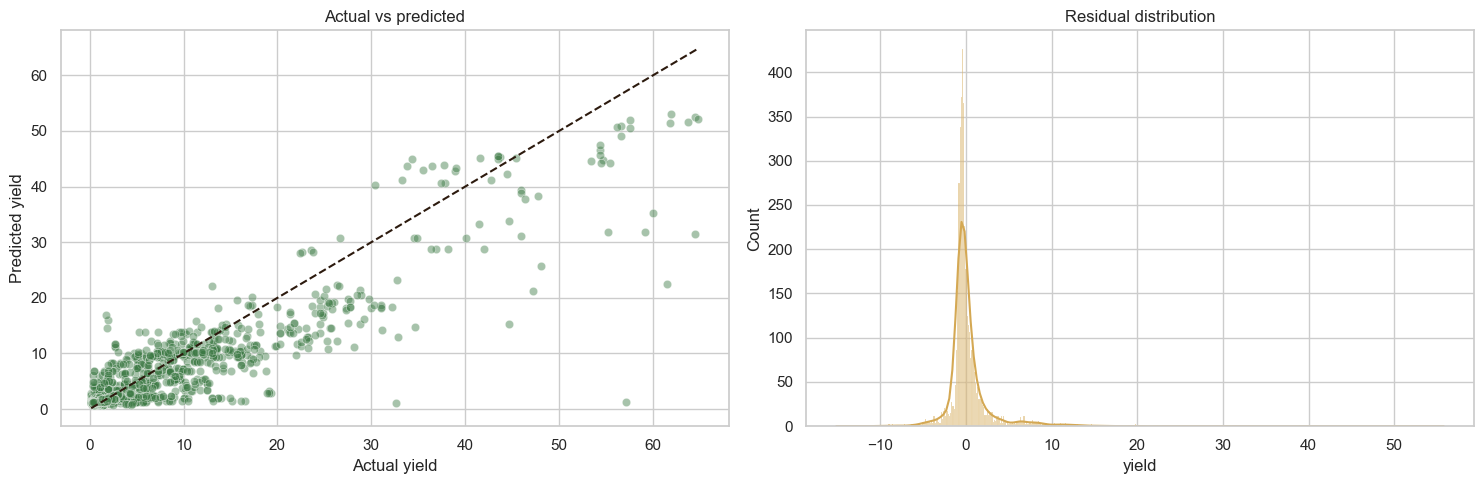

,feature,importance
76,categorical__crop_sugarcane,0.258856
33,categorical__crop_banana,0.073393
67,categorical__crop_potato,0.045492
88,categorical__season_whole year,0.039961
4,categorical__state_chhattisgarh,0.035047
79,categorical__crop_tapioca,0.034976
9,categorical__state_himachal pradesh,0.030404
61,categorical__crop_onion,0.027775
18,categorical__state_mizoram,0.026966
43,categorical__crop_dry chillies,0.022908


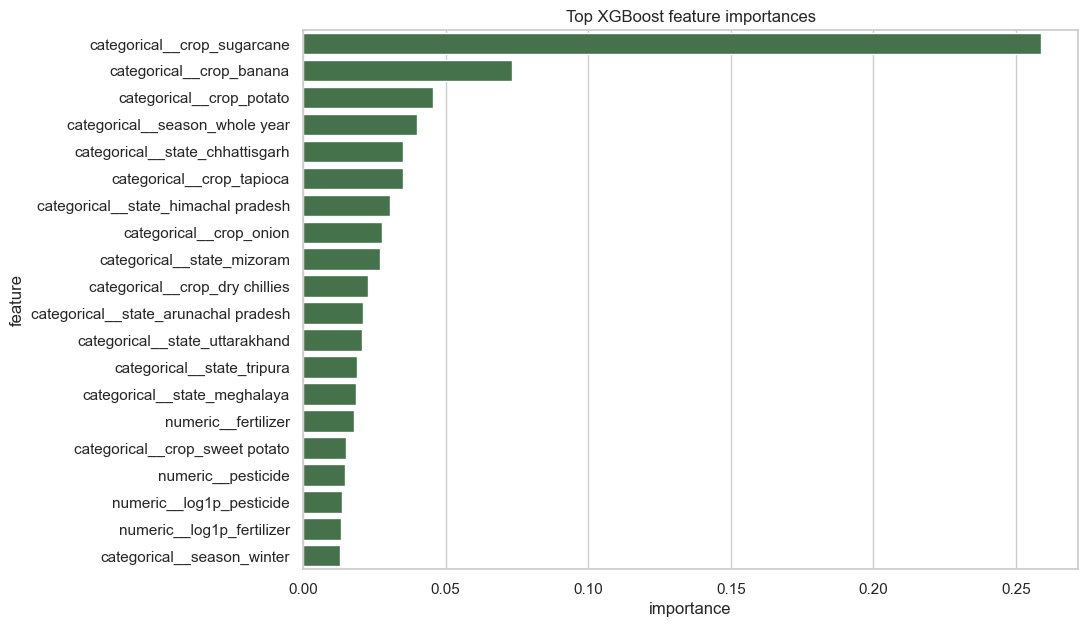

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], color='#3d7a45', alpha=0.45)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='#2c1a0e')
axes[0].set(xlabel='Actual yield', ylabel='Predicted yield', title='Actual vs predicted')
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='#d4a853')
axes[1].set_title('Residual distribution')
plt.tight_layout()
plt.show()

encoded_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
importance = pipeline.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({'feature': encoded_names, 'importance': importance}).sort_values('importance', ascending=False).head(20)
display(importance_df)
plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, x='importance', y='feature', color='#3d7a45')
plt.title('Top XGBoost feature importances')
plt.show()

## 7. Save a candidate artifact bundle

The bundle is saved separately so this notebook never silently replaces the currently deployed model. The Flask application would need a small adapter for this pipeline because the new dataset has different fields and uses one-hot encoding instead of the current label-encoder/scaler contract.

In [8]:
joblib.dump(pipeline, OUTPUT_DIR / 'yield_xgb_pipeline.pkl')
joblib.dump(feature_columns, OUTPUT_DIR / 'feature_columns.pkl')
joblib.dump({c: sorted(work[c].dropna().unique().tolist()) for c in categorical_features}, OUTPUT_DIR / 'unique_values.pkl')
metrics.update({
    'model': 'XGBoost with one-hot categorical preprocessing',
    'dataset': 'crop_yield.csv',
    'target': 'yield',
    'leakage_removed': ['production'],
    'outlier_filter': 'target 2nd-98th percentiles',
    'train_years': f"{int(work.loc[train_mask, 'crop_year'].min())}-{cutoff}",
    'test_years': f"{cutoff + 1}-{int(work.loc[test_mask, 'crop_year'].max())}",
})
with (OUTPUT_DIR / 'metrics.json').open('w', encoding='utf-8') as handle:
    json.dump(metrics, handle, indent=2)
print('Saved candidate artifacts:')
for path in sorted(OUTPUT_DIR.iterdir()):
    print(' -', path)

Saved candidate artifacts:
 - /Users/ayushvishnoi/Documents/GitHub/smart_harvest.ai/models/yield_model_crop_yield_candidate/feature_columns.pkl
 - /Users/ayushvishnoi/Documents/GitHub/smart_harvest.ai/models/yield_model_crop_yield_candidate/metrics.json
 - /Users/ayushvishnoi/Documents/GitHub/smart_harvest.ai/models/yield_model_crop_yield_candidate/unique_values.pkl
 - /Users/ayushvishnoi/Documents/GitHub/smart_harvest.ai/models/yield_model_crop_yield_candidate/yield_xgb_pipeline.pkl


## Production replacement checklist

1. Compare this candidate's time-based metrics against the current model.
2. Decide whether the changed feature contract is acceptable: `crop_yield.csv` does not include the current app's district/geospatial/soil/humidity fields.
3. If accepted, add a Flask prediction adapter that loads `yield_xgb_pipeline.pkl` and maps only the new dataset fields.
4. Update `frontend/yield.html`, API validation, tests, setup validation, and documentation together.
5. Only then promote the candidate bundle into `models/yield_model/`; this notebook intentionally does not do that automatically.